In [1]:
# Перед началом работы с библиотеками pandas и seaborn необходимо установить их в Python.
# Сделать это можно, исполнив данную ячейку
!pip3 install pandas
!pip3 install seaborn

In [3]:
import matplotlib
print(matplotlib.__version__)

3.8.4


In [7]:
import math

import pandas as pd
import seaborn as sns

In [8]:
# Настройка, которая позволяет сделать графики, которые рисует seaborn, более крупными
sns.set(rc={'figure.figsize': (11.7, 8.27)})

In [9]:
def round_to_2(x):
    """
    Принимает число и возвращает результат его округления
    до 2 знаков после запятой.
    
    Аргументы:
        x: Число.
        
    Возвращаемое значение:
        Результат округления числа до 2 знаков после запятой.
    """
    
    return round(x, 2)

## Среднее значение в колонке csv-файла

In [14]:
def split_line(line, sep):
    """
    Возвращает список значений, которые содержатся в строке
    и разделены конкретным разделителем.
    Если какое-то из значений обособлено кавычками ("<значение>"), то разделительный
    символ внутри него не считается разделителем.
    
    Например, если передать в функцию строку 'aa,bb,"cc, oo",dd' и разделитель ',',
    то в результате работы функции получится список ['aa', 'bb', 'cc, oo', 'dd'].
    
    Аргументы:
        line: Строка, которую нужно разбить на подстроки.
        sep: Разделитель, который используется в строке для отделения различных значений.
        
    Возвращаемое значение:
        Список подстрок строки, получаемых с помощью разделения её
        на подстроки по заданному разделителю.
    """
    
    res = []
    
    prev_ind = -1
    in_quotes = False
    
    for i in range(len(line)):
        ch = line[i]
        
        if ch == '"':
            in_quotes = not in_quotes
            
        if not in_quotes and ch == sep:
            res.append(line[prev_ind + 1:i].strip('"'))
            prev_ind = i
            
    if prev_ind < len(line) - 1:
        res.append(line[prev_ind + 1:len(line)].strip('"'))
    elif prev_ind == len(line) - 1:
        res.append('')
    
    return res

In [22]:
def read_csv_and_calc_mean_solution(lines, sep, column_name):
    d = split_line(lines[0], sep)
    n = len(d)
    fl = 0
    for i in range(n):
        if d[i] == column_name:
            fl = i
            break
    sum = 0
    k = 0
    m = len(lines)
    for i in range(1, m):
        h = split_line(lines[i], sep)
        sum += int(h[fl])
        k += 1
    

    
    """
    Принимает список строк из csv-файла и возвращает среднее значение в заданной колонке.
    В первой строке csv-файла всегда представлены названия его колонок.
    
    Аргументы:
        lines: Список строк, прочитанных из csv-файла.
        sep: Разделитель, который используется в строках для отделения различных значений.
        column_name: Название колонки с целочисленными значениями, по которой нужно посчитать среднее.
        
    Возвращаемое значение:
        Среднее значение в заданной колонке, округлённое до 2 знаков
        после запятой с помощью функции round_to_2.
    """
    return round_to_2(sum/k)
    pass

In [24]:
def read_csv_and_calc_mean_tests():
    example_1_lines = [
        'Жанр,"Продолжительность, часы","Продолжительность, минуты",Страна производства,Год производства',
        'Боевик,0,36,Италия,1996',
        'Комедия,1,23,Россия,1999',
        'Триллер,2,21,США,2006',
    ]
    example_1_sep = ','
    example_1_column = 'Год производства'
    example_1_res = 2000.33
    
    assert read_csv_and_calc_mean_solution(example_1_lines, example_1_sep, example_1_column) == example_1_res
    
    example_2_lines = [
        'Жанр,"Продолжительность, часы","Продолжительность, минуты",Страна производства,Год производства',
        'Боевик,0,36,Италия,1996',
        'Комедия,1,23,Россия,1999',
        'Триллер,2,21,США,2006',
        'Комедия,1,48,США-Россия,2012',
        'Драма,2,3,Франция,2016',
        'Документальный,2,47,Германия,2001'
    ]
    example_2_sep = ','
    example_2_column = 'Продолжительность, минуты'
    example_2_res = 29.67
    
    assert read_csv_and_calc_mean_solution(example_2_lines, example_2_sep, example_2_column) == example_2_res
    
    print('Все тесты прошли успешно!')

In [26]:
read_csv_and_calc_mean_tests()

Все тесты прошли успешно!


## Фильтрация таблиц

In [52]:
# В переменную movies загружена таблица из файла movies_data.csv
movies = pd.read_csv('movies_data.csv', sep=',')

# Удаление фильмов, у которых не указан год производства
movies = movies[~movies['Год производства'].isna()]
#ans = movies[(movies['Жанр фильма'] == 'Драма') & (movies['Страна производства']=='Франция')]
ans = movies[(movies['Страна производства']=='Россия') | ((movies['Год производства'] < 2000)&(movies['Жанр фильма']=='Триллер'))]
print(len(ans))


3299


## Комбинирование колонок и расчёт статистик

In [88]:
# В переменную movies_budget загружена таблица из файла movies_budget.csv
movies_budget = pd.read_csv('movies_budget.csv', sep=';')
print(movies_budget)
movies_budget['Доход'] = movies_budget['Число зрителей'] * movies_budget['Стоимость билета'] 
movies_budget['Прибыль'] = movies_budget['Доход']*0.5 - movies_budget['Бюджет'] - movies_budget['Бюджет'] * (1/2)
print(round_to_2(movies_budget['Прибыль'].max()))

    Жанр фильма Страна производства   Бюджет  Число зрителей  Стоимость билета
0         Драма                 США  5932617          465141               350
1       Триллер            Германия  1007872          141702               220
2       Триллер             Франция  1277422          114760               350
3       Комедия      Россия-Франция   880262           71666               400
4        Боевик              Россия  2114068           96311               400
..          ...                 ...      ...             ...               ...
995       Драма              Россия  1386295          535015               400
996       Драма    Германия-Франция  1083350          314686               220
997      Боевик    Германия-Франция  1213386           85184               400
998      Боевик    Германия-Франция   884198          123489               350
999       Драма              Италия   635273          438191               350

[1000 rows x 5 columns]
150431902.0


## Агрегированные статистики

In [96]:
# В переменную movies_budget загружена таблица из файла movies_budget.csv
movies_budget = pd.read_csv('movies_budget.csv', sep=';')

print(movies_budget.groupby('Жанр фильма', as_index=False).aggregate({'Число зрителей': 'sum'}).sort_values('Число зрителей', ascending=False))




      Жанр фильма  Число зрителей
2           Драма       144536483
4         Триллер        30519114
0          Боевик        20859969
1  Документальный        10093471
3         Комедия         9920914


In [98]:
def transform_countries_info(movies_data):
    """
    Принимает таблицу с колонкой «Страна производства» и добавляет к таблице 5 новых колонок:
    по одной на каждую отдельную страну. Значение в каждой из колонок соответствует тому,
    принимала ли конкретная страна участие в производстве фильма.
    
    Аргументы:
        movies_data: Исходная таблица с клонкой «Страна производства».
        
    Возвращаемое значение:
        Нет. Функция модифицирует переданную таблицу, но ничего не возвращает.
    """
    
    countries = ['Россия', 'Германия', 'США', 'Италия', 'Франция']
    new_columns = [[] for i in range(len(countries))]
    
    for _, row in movies_data.iterrows():
        country_of_origin_united = row['Страна производства']
        countries_of_origin = country_of_origin_united.split('-')
        
        for i in range(len(countries)):
            country = countries[i]
            
            if country in countries_of_origin:
                new_columns[i].append('Да')
            else:
                new_columns[i].append('Нет')
                
    for i in range(len(countries)):
        movies_data[countries[i]] = new_columns[i]

In [102]:
print(transform_countries_info(movies_budget))

None


## Визуальный анализ данных

<Axes: xlabel='D', ylabel='E'>

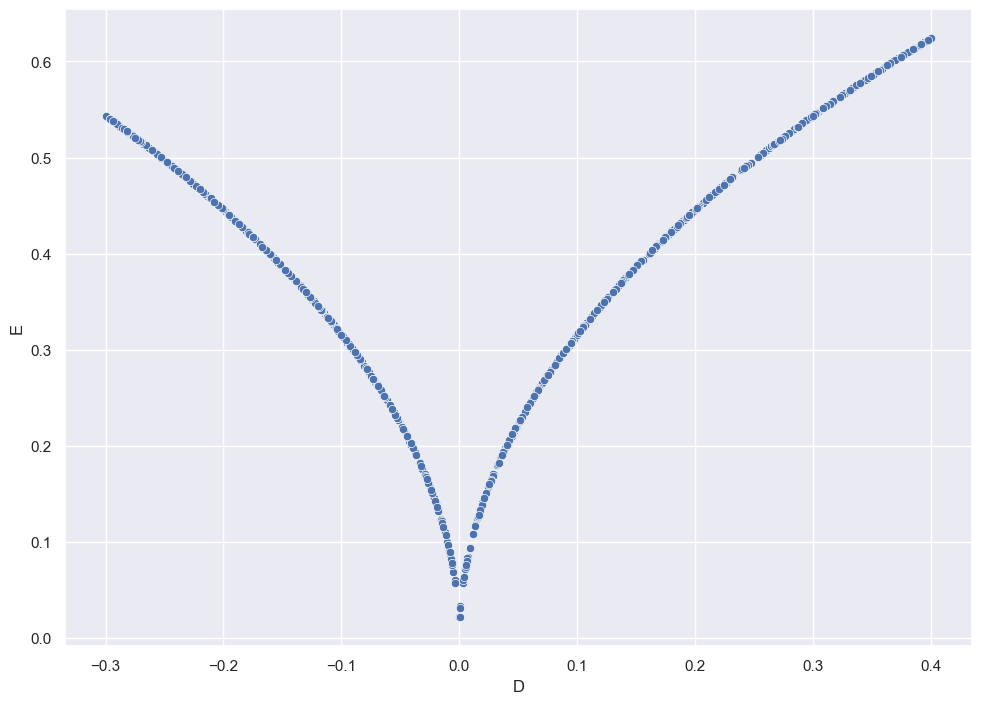

In [136]:
# В переменную many_factors загружена таблица из файла many_factors_data.csv
many_factors = pd.read_csv('many_factors_data.csv')
sns.scatterplot(data=many_factors,
                x='D',
                y='E')

<Axes: xlabel='D', ylabel='Count'>

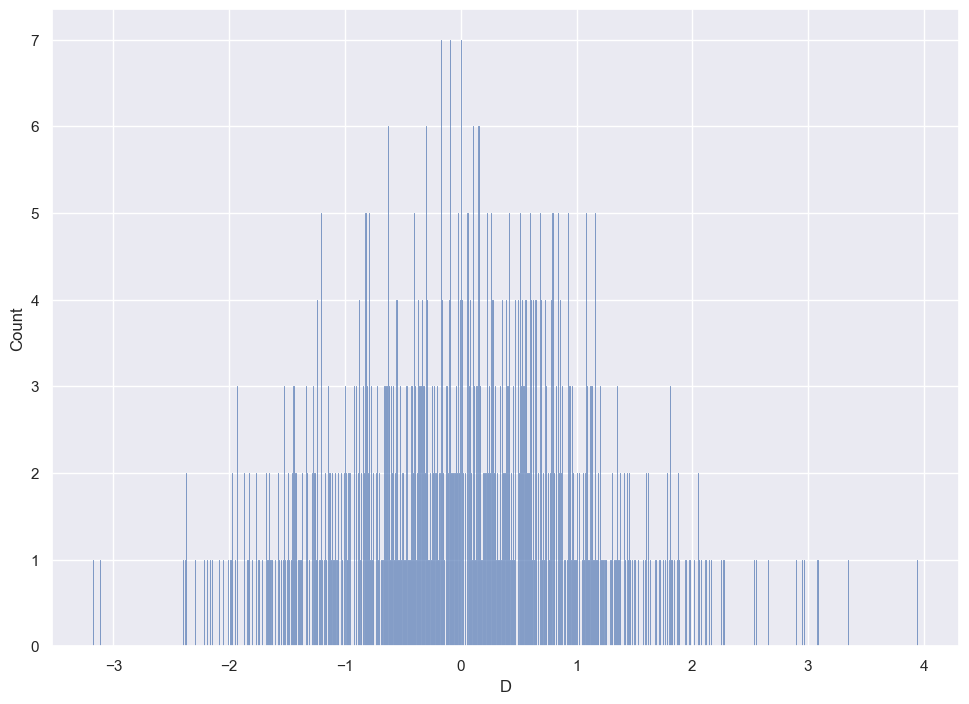

In [158]:
# В переменную uniform_and_not загружена таблица из файла uniform_and_not_data
uniform_and_not = pd.read_csv('uniform_and_not_data.csv')
sns.histplot(uniform_and_not['D'],
             bins=len(uniform_and_not['D'].unique()))